<a href="https://colab.research.google.com/github/jiki007/OS_project/blob/main/Chatbot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install matplotlib

import subprocess
import datetime
import matplotlib.pyplot as plt
from collections import Counter

#Logging storage
command_log = []

In [ ]:
def run_ubuntu_cmd(cmd):
  result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
  return result.stdout if result.stdout else result.stderr

In [ ]:
def log_command(command):
    command_log.append({
        "command": command,
        "time": datetime.datetime.now().strftime("%H:%M:%S")
    })

def chatbot(user_input):
    user_input = user_input.lower().strip()
    log_command(user_input)

    if "disk space" in user_input:
        output = run_ubuntu_cmd("df -h")
        return f"💾 Disk Space (Ubuntu df -h):\n{output}"

    elif "list processes" in user_input or "running processes" in user_input:
        output = run_ubuntu_cmd("ps aux --sort=-%mem | head -15")
        return f"⚙️ Running Processes (Ubuntu ps aux):\n{output}"

    elif "kill process" in user_input:
        parts = user_input.split()
        try:
            pid = int(parts[-1])
            output = run_ubuntu_cmd(f"kill -9 {pid} 2>&1 || echo 'Simulated: Process {pid} terminated.'")
            return f"🔴 Kill Process Result:\n{output}"
        except:
            return "⚠️ Please specify a valid PID. Example: 'kill process 1234'"

    elif "cpu" in user_input:
        output = run_ubuntu_cmd("top -bn1 | grep 'Cpu(s)'")
        return f"🖥️ CPU Usage (Ubuntu top):\n{output}"

    elif "memory" in user_input or "ram" in user_input:
        output = run_ubuntu_cmd("free -h")
        return f"🧠 Memory Info (Ubuntu free -h):\n{output}"

    elif "uptime" in user_input:
        output = run_ubuntu_cmd("uptime -p")
        return f"⏱️ System Uptime (Ubuntu uptime):\n{output}"

    elif "os info" in user_input:
        output = run_ubuntu_cmd("uname -a && lsb_release -a 2>/dev/null")
        return f"🐧 OS Info (Ubuntu uname):\n{output}"

    elif "network" in user_input:
        output = run_ubuntu_cmd("ifconfig 2>/dev/null || ip addr show")
        return f"🌐 Network Info:\n{output}"

    elif "logged in users" in user_input or "who" in user_input:
        output = run_ubuntu_cmd("who")
        return f"👥 Logged In Users (Ubuntu who):\n{output}"

    elif "show stats" in user_input:
        visualize_logs()
        return "📊 Charts displayed!"

    elif "help" in user_input:
        return (
            "🆘 Available Commands:\n"
            "  - check disk space\n"
            "  - list running processes\n"
            "  - kill process <PID>\n"
            "  - check cpu\n"
            "  - check memory / ram\n"
            "  - check uptime\n"
            "  - check os info\n"
            "  - check network\n"
            "  - logged in users\n"
            "  - show stats\n"
            "  - exit"
        )

    elif "exit" in user_input:
        return "👋 Goodbye! Chatbot session ended."

    else:
        return "❓ Unknown command. Type 'help' to see available commands."

In [ ]:
def visualize_logs():
    if not command_log:
        print("No commands logged yet.")
        return

    # Categorize commands
    categories = []
    for entry in command_log:
        cmd = entry["command"]
        if "disk" in cmd:             categories.append("disk space")
        elif "process" in cmd:        categories.append("processes")
        elif "kill" in cmd:           categories.append("kill process")
        elif "cpu" in cmd:            categories.append("cpu")
        elif "memory" in cmd or "ram" in cmd: categories.append("memory/ram")
        elif "uptime" in cmd:         categories.append("uptime")
        elif "os" in cmd:             categories.append("os info")
        elif "network" in cmd:        categories.append("network")
        elif "who" in cmd or "user" in cmd:   categories.append("users")
        else:                         categories.append("other")

    counts = Counter(categories)

    # Bar chart
    plt.figure(figsize=(10, 5))
    plt.bar(counts.keys(), counts.values(), color='steelblue', edgecolor='black')
    plt.title("\nChatbot Command Frequency\n", fontsize=14)
    plt.xlabel("Command Type")
    plt.ylabel("Times Used")
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()
    print(80*'-')
    # Timeline
    times = [e["time"] for e in command_log]
    cmds = [e["command"][:20] for e in command_log]

    plt.figure(figsize=(12, 4))
    plt.plot(times, range(len(times)), marker='o', color='coral')
    for i, (t, c) in enumerate(zip(times, cmds)):
        plt.annotate(c, (t, i), textcoords="offset points", xytext=(5, 0), fontsize=7)
    plt.title("\nCommand Timeline\n", fontsize=14)
    plt.xlabel("Time")
    plt.ylabel("Command #")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

🤖 Ubuntu OS Automation Chatbot
Type 'help' for commands | 'exit' to quit

You: show stats


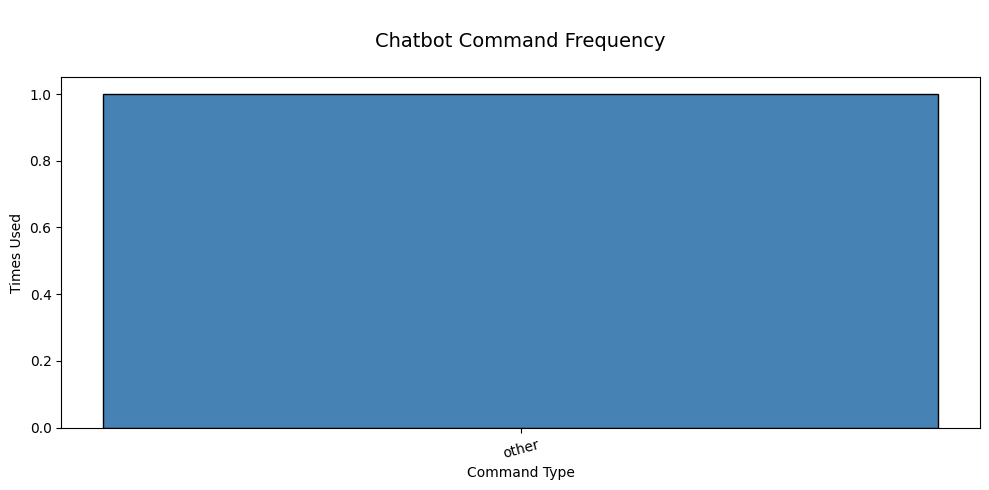

--------------------------------------------------------------------------------


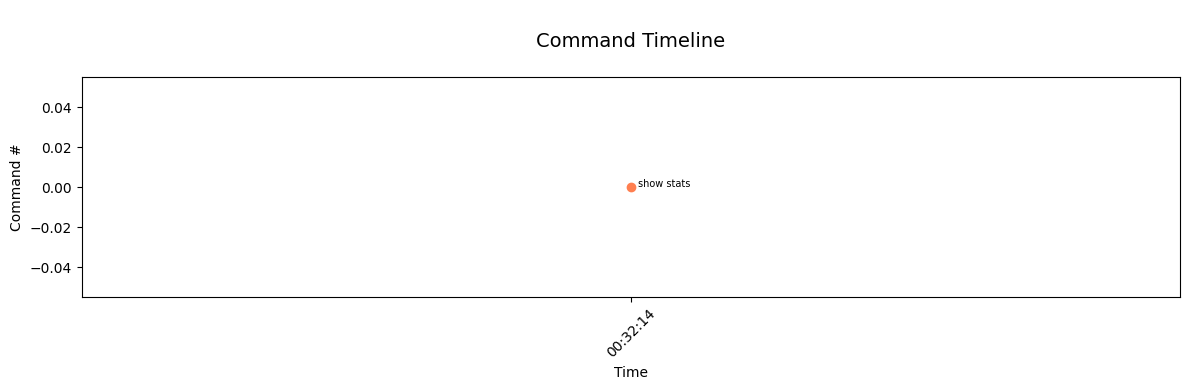


Bot: 📊 Charts displayed!

You: exit

Bot: 👋 Goodbye! Chatbot session ended.



In [ ]:
print("🤖 Ubuntu OS Automation Chatbot")
print("Type 'help' for commands | 'exit' to quit\n")

while True:
    user_input = input("You: ")
    response = chatbot(user_input)
    print(f"\nBot: {response}\n")
    if "exit" in user_input.lower():
        break

🤖 Ubuntu OS Chatbot — Demo Mode

You: check disk space
Bot: 💾 Disk Space (Ubuntu df -h):
Filesystem      Size  Used Avail Use% Mounted on
overlay         108G   21G   88G  19% /
tmpfs            64M     0   64M   0% /dev
shm             5.7G     0  5.7G   0% /dev/shm
/dev/root       2.0G  1.3G  696M  65% /usr/sbin/docker-init
tmpfs           6.4G  788K  6.4G   1% /var/colab
/dev/sda1       114G   22G   93G  19% /kaggle/input
tmpfs           6.4G     0  6.4G   0% /proc/acpi
tmpfs           6.4G     0  6.4G   0% /proc/scsi
tmpfs           6.4G     0  6.4G   0% /sys/firmware


--------------------------------------------------
You: list running processes
Bot: ⚙️ Running Processes (Ubuntu ps aux):
USER         PID %CPU %MEM    VSZ   RSS TTY      STAT START   TIME COMMAND
root        6766 40.2  2.0 1785904 279020 ?      Sl   00:32   0:07 node /datalab/web/pyright/pyright-langserver.js --stdio --cancellationReceive=file:ba4369e431ff7147dcfba22835b71387a1c2ff14c4
root          87  0.4  1.1 41

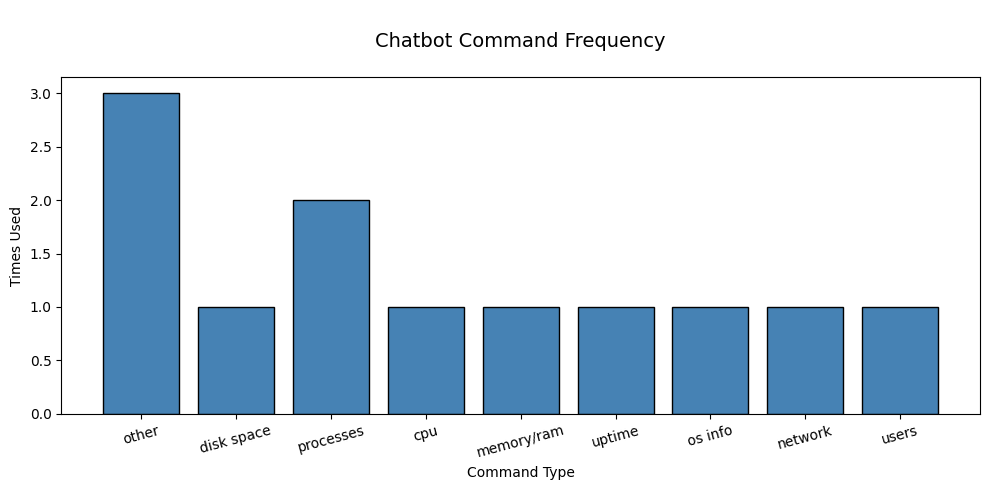

--------------------------------------------------------------------------------


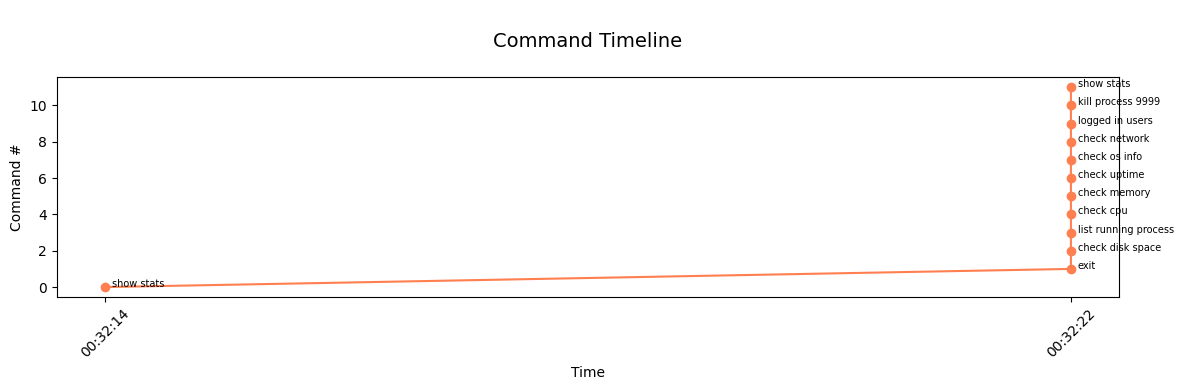

Bot: 📊 Charts displayed!

--------------------------------------------------


In [ ]:
demo_inputs = [
    "check disk space",
    "list running processes",
    "check cpu",
    "check memory",
    "check uptime",
    "check os info",
    "check network",
    "logged in users",
    "kill process 9999",
    "show stats"
]

print("🤖 Ubuntu OS Chatbot — Demo Mode\n")
for cmd in demo_inputs:
    print(f"You: {cmd}")
    print(f"Bot: {chatbot(cmd)}\n")
    print("-" * 50)